### Overview
 * Author: AzG
 * Create Time: 2025-06-25 12:19:51
 * Modified by: AzG
 * Modified time: 2025-12-15 23:58:40
 * Description: Surrogate model construction, evaluation, sensitivity and probabilistic analysis.

### Import packages and modules

In [1]:
from deepxtwin.sampling import SamplingModel
from pathlib import Path
import os
from deepxtwin.surrogate import PCE_Surrogate_Builder
from deepxtwin.surrogate import PCE_Surrogate_Analyzer 
from deepxtwin.surrogate import InputDistributionFactory
from deepxtwin.surrogate import UQAnalysis

### User INPUT

In [2]:
# Set project root folder path and current working directory path
PROJECT_ROOT = Path.cwd().parents[2]  
CWD_PATH = Path.cwd()
print(PROJECT_ROOT)

c:\Users\AzG\OneDrive - NGI\01_Projects\02_Campus_Ullevål\azure\sp14-wp4-deepxtwin


In [3]:
# Specify file paths and parameters
configpath = PROJECT_ROOT / "config.toml"                       # design variable specifications to generate joint probability distribution according to sampling plan
design_vars_fos_file = CWD_PATH / "designvars_fos_data.csv"     # input data file with design variables and FoS results

train_fraction = 0.8                                            # according to Zhang et al. (2024) and Zheng et al. (2023)
max_degree = 4                                                  # affects truncation of polynomial chaos expansion
n_samples = 500                                                 # number of samples to generate joint probability distribution according to sampling plan

### Load, prepare and inspect data

In [4]:
# Generate surrogate model instance
# NOTE: The fos_col_idx corresponds to the column index in the input CSV file where the target FoS values are located.
surrogate_model_excavation = PCE_Surrogate_Builder(design_vars_fos_file, fos_col_idx=14)
surrogate_model_cantilever = PCE_Surrogate_Builder(design_vars_fos_file, fos_col_idx=15)

In [5]:
# Check inconsistent data before cleaning (raw data with NaN or missing values)
surrogate_model_cantilever.inspect_rawdata()
surrogate_model_excavation.inspect_rawdata()

Data shape: (500, 16)
Columns:
0: ribs_su_clay
1: ribs_su_LC
2: ribs_E_clay
3: ribs_E_LC
4: ribs_L_col
5: ribs_L_rib
6: ribs_c_rib
7: ribs_d_rib
8: Leire1_GURsUARatio
9: Leire1_gammaFC
10: Leire2_GURsUARatio
11: Leire2_gammaFC
12: Leire1_sUARef
13: Leire2_sUARef
14: FoS interim
15: FoS end
Number of rows with at least one NaN or missing value: 7
First few rows:
   ribs_su_clay  ribs_su_LC  ribs_E_clay  ribs_E_LC  ribs_L_col  ribs_L_rib  \
0         33.80      231.18         6300      75000       16.17       24.64   
1         57.71      258.47         6300      75000       24.24       15.70   
2         26.62      259.01         6300      75000       20.82       24.69   
3         40.48      285.37         6300      75000       18.63       23.31   
4         64.58      228.68         6300      75000       21.01       15.39   

   ribs_c_rib  ribs_d_rib  Leire1_GURsUARatio  Leire1_gammaFC  \
0        1.30         0.6                 700             0.9   
1        2.77         0.6      

In [6]:
# Show all rows where column at position 14 is NaN
surrogate_model_cantilever.data[surrogate_model_cantilever.data.iloc[:, 15].isna()]

# NOTE: The rows with NaN values correspond to non-converged simulations in PLAXIS.

,ribs_su_clay,ribs_su_LC,ribs_E_clay,ribs_E_LC,ribs_L_col,ribs_L_rib,ribs_c_rib,ribs_d_rib,Leire1_GURsUARatio,Leire1_gammaFC,Leire2_GURsUARatio,Leire2_gammaFC,Leire1_sUARef,Leire2_sUARef,FoS interim,FoS end
14,16.33,340.27,6300,75000,19.19,24.04,2.33,0.6,700,0.9,700,1.0,16.33,16.33,0.9306,NaN
29,19.00,290.34,6300,75000,16.39,18.73,1.10,0.6,700,0.9,700,1.0,19.00,19.00,0.8590,NaN
79,20.65,202.84,6300,75000,16.75,15.00,1.44,0.6,700,0.9,700,1.0,20.65,20.65,0.8558,NaN
120,22.70,312.01,6300,75000,15.29,21.55,1.76,0.6,700,0.9,700,1.0,22.70,22.70,0.9740,NaN
306,19.30,292.48,6300,75000,18.65,21.46,2.67,0.6,700,0.9,700,1.0,19.30,19.30,0.9962,NaN
341,19.87,284.35,6300,75000,14.74,24.73,2.51,0.6,700,0.9,700,1.0,19.87,19.87,0.8921,NaN
456,22.13,253.27,6300,75000,18.03,17.47,2.91,0.6,700,0.9,700,1.0,22.13,22.13,0.9959,NaN


In [7]:
df = surrogate_model_cantilever.data[surrogate_model_cantilever.data.iloc[:, :].isna()]

In [8]:
df = surrogate_model_cantilever.data
df

,ribs_su_clay,ribs_su_LC,ribs_E_clay,ribs_E_LC,ribs_L_col,ribs_L_rib,ribs_c_rib,ribs_d_rib,Leire1_GURsUARatio,Leire1_gammaFC,Leire2_GURsUARatio,Leire2_gammaFC,Leire1_sUARef,Leire2_sUARef,FoS interim,FoS end
0,33.80,231.18,6300,75000,16.17,24.64,1.30,0.6,700,0.9,700,1.0,33.80,33.80,1.354180,2.107225
1,57.71,258.47,6300,75000,24.24,15.70,2.77,0.6,700,0.9,700,1.0,57.71,57.71,2.044828,2.836594
2,26.62,259.01,6300,75000,20.82,24.69,2.86,0.6,700,0.9,700,1.0,26.62,26.62,1.306000,1.953000
3,40.48,285.37,6300,75000,18.63,23.31,2.83,0.6,700,0.9,700,1.0,40.48,40.48,1.644000,2.340000
4,64.58,228.68,6300,75000,21.01,15.39,2.43,0.6,700,0.9,700,1.0,64.58,64.58,2.201000,3.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,41.40,335.88,6300,75000,22.70,21.35,1.56,0.6,700,0.9,700,1.0,41.40,41.40,1.678000,2.376000
496,30.51,304.83,6300,75000,19.95,24.76,1.35,0.6,700,0.9,700,1.0,30.51,30.51,1.372000,2.041000
497,29.74,180.97,6300,75000,19.50,22.54,1.66,0.6,700,0.9,700,1.0,29.74,29.74,1.316000,1.997000
498,44.41,236.27,6300,75000,18.17,26.13,1.95,0.6,700,0.9,700,1.0,44.41,44.41,1.698000,2.514000


In [9]:
# Clean data by removing rows with NaN values = non-converged solutions
surrogate_model_cantilever.clean_rawdata()
surrogate_model_excavation.clean_rawdata()

Shape of cleaned dataset: (493, 16)
Shape of cleaned dataset: (500, 16)


### Train/Test split

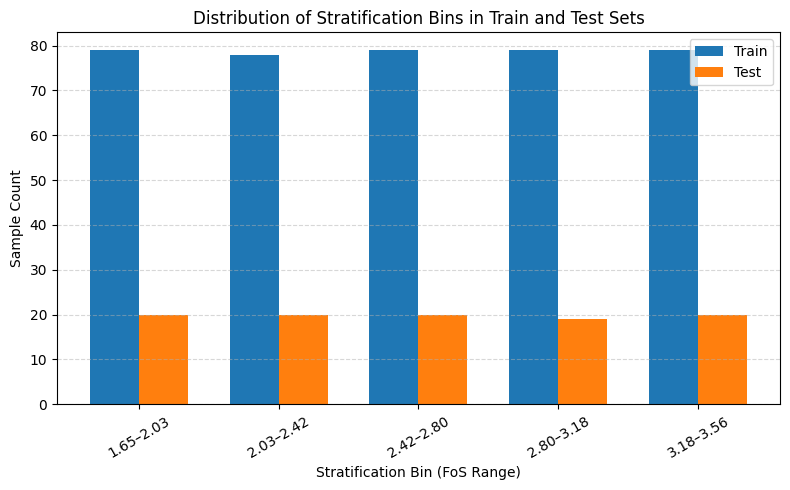

In [10]:
surrogate_model_cantilever.train_test_split(design_vars_idx=[4, 5, 6, 1, 0],    # Order should adhere to arrangement of probability density distribution during sampling
                                            train_fraction=train_fraction, 
                                            n_bins=5, 
                                            plot_bin_distribution=True)

# NOTE: The total number of samples < 500 after cleaning due to removal of non-converged simulations.

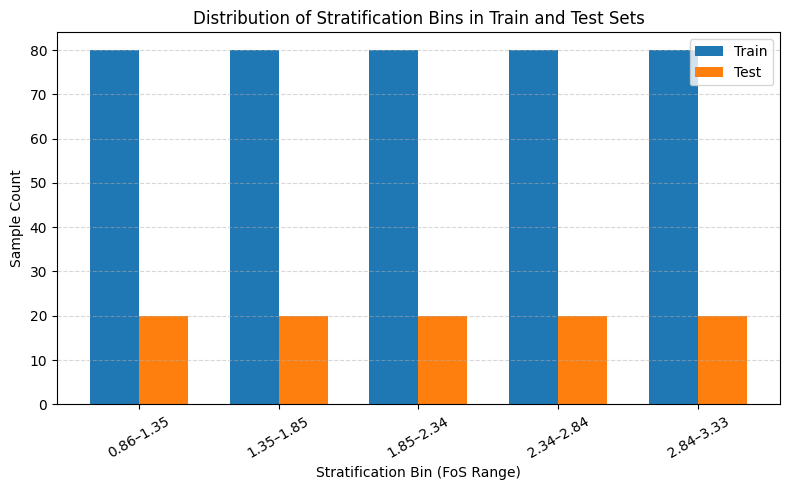

In [11]:
surrogate_model_excavation.train_test_split(design_vars_idx=[4, 5, 6, 1, 0],    # should adhere to arrangement of probability density distribution during sampling
                                            train_fraction=train_fraction, 
                                            n_bins=5, 
                                            plot_bin_distribution=True)

# NOTE: The total number of samples = 500 after cleaning as FoS values < 1.0 are sampled in SRFEA phase.

In [12]:
# Check training data
print(f"Feature matrix:\n{surrogate_model_cantilever.X_train[:5]},\nTargets:\n{surrogate_model_cantilever.y_train[:5]}")

Feature matrix:
[[ 19.97  25.4    1.25 227.89  28.44]
 [ 19.42  14.7    2.73 239.08  40.77]
 [ 19.63  19.82   2.97 193.69  51.62]
 [ 22.83  26.02   2.04 204.51  47.82]
 [ 23.35  28.59   2.07 307.07  47.9 ]],
Targets:
[2.018 2.217 2.647 2.652 2.736]


In [13]:
# Check testing data
print(f"5 minimum values in y_test:\n{sorted(surrogate_model_excavation.y_test)[:5]}")

5 minimum values in y_test:
[np.float64(0.974), np.float64(0.9962), np.float64(1.007), np.float64(1.02056947198908), np.float64(1.025)]


### Train PCE surrogate

In [14]:
sampling_model = SamplingModel(configpath=configpath, n_samples=n_samples)
joint_dist = sampling_model.generate_joint_propability_distribution()

In [15]:
# Inspect the generated joint distribution
joint_dist

J(Uniform(lower=14.5, upper=25.0), Uniform(lower=14.5, upper=29.0), Uniform(lower=1.0, upper=3.0), Uniform(lower=175, upper=350), LogNormal(mu=3.694580770162842, sigma=0.293560379208524))

Degree 1: Mean CV R² = 0.9941, MAE = 0.0187, NRMSE = 0.0156
Degree 2: Mean CV R² = 0.9979, MAE = 0.0111, NRMSE = 0.0092
Degree 3: Mean CV R² = 0.9978, MAE = 0.0110, NRMSE = 0.0093
Degree 4: Mean CV R² = 0.9962, MAE = 0.0146, NRMSE = 0.0125
Best polynomial degree: 2


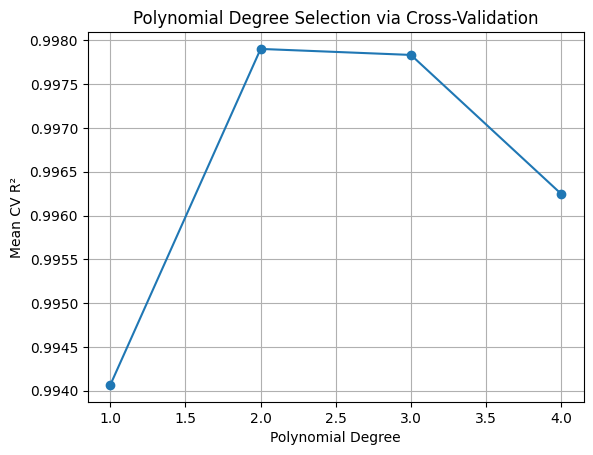

In [16]:
surrogate_model_cantilever.train_pce_model(joint_dist=joint_dist)

Degree 1: Mean CV R² = 0.9763, MAE = 0.0409, NRMSE = 0.0279
Degree 2: Mean CV R² = 0.9750, MAE = 0.0407, NRMSE = 0.0287
Degree 3: Mean CV R² = 0.9684, MAE = 0.0437, NRMSE = 0.0322
Degree 4: Mean CV R² = 0.9496, MAE = 0.0527, NRMSE = 0.0399
Best polynomial degree: 1


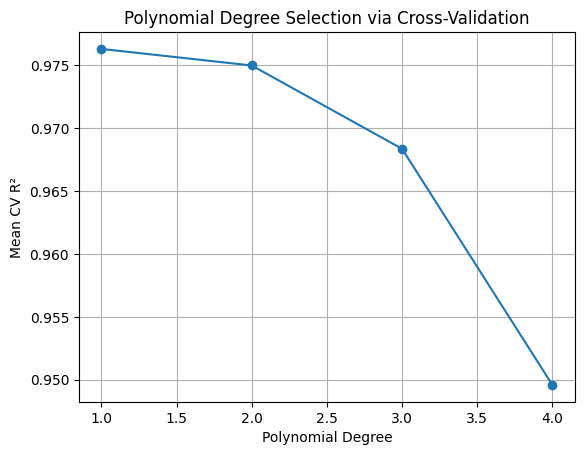

In [17]:
surrogate_model_excavation.train_pce_model(joint_dist=joint_dist)

### Evaluate PCE surrogate

In [18]:
surrogate_analyzer = PCE_Surrogate_Analyzer([surrogate_model_excavation, surrogate_model_cantilever])

Test R²: 0.9814
Test NRMSE: 0.0276
Test MAE: 0.0376


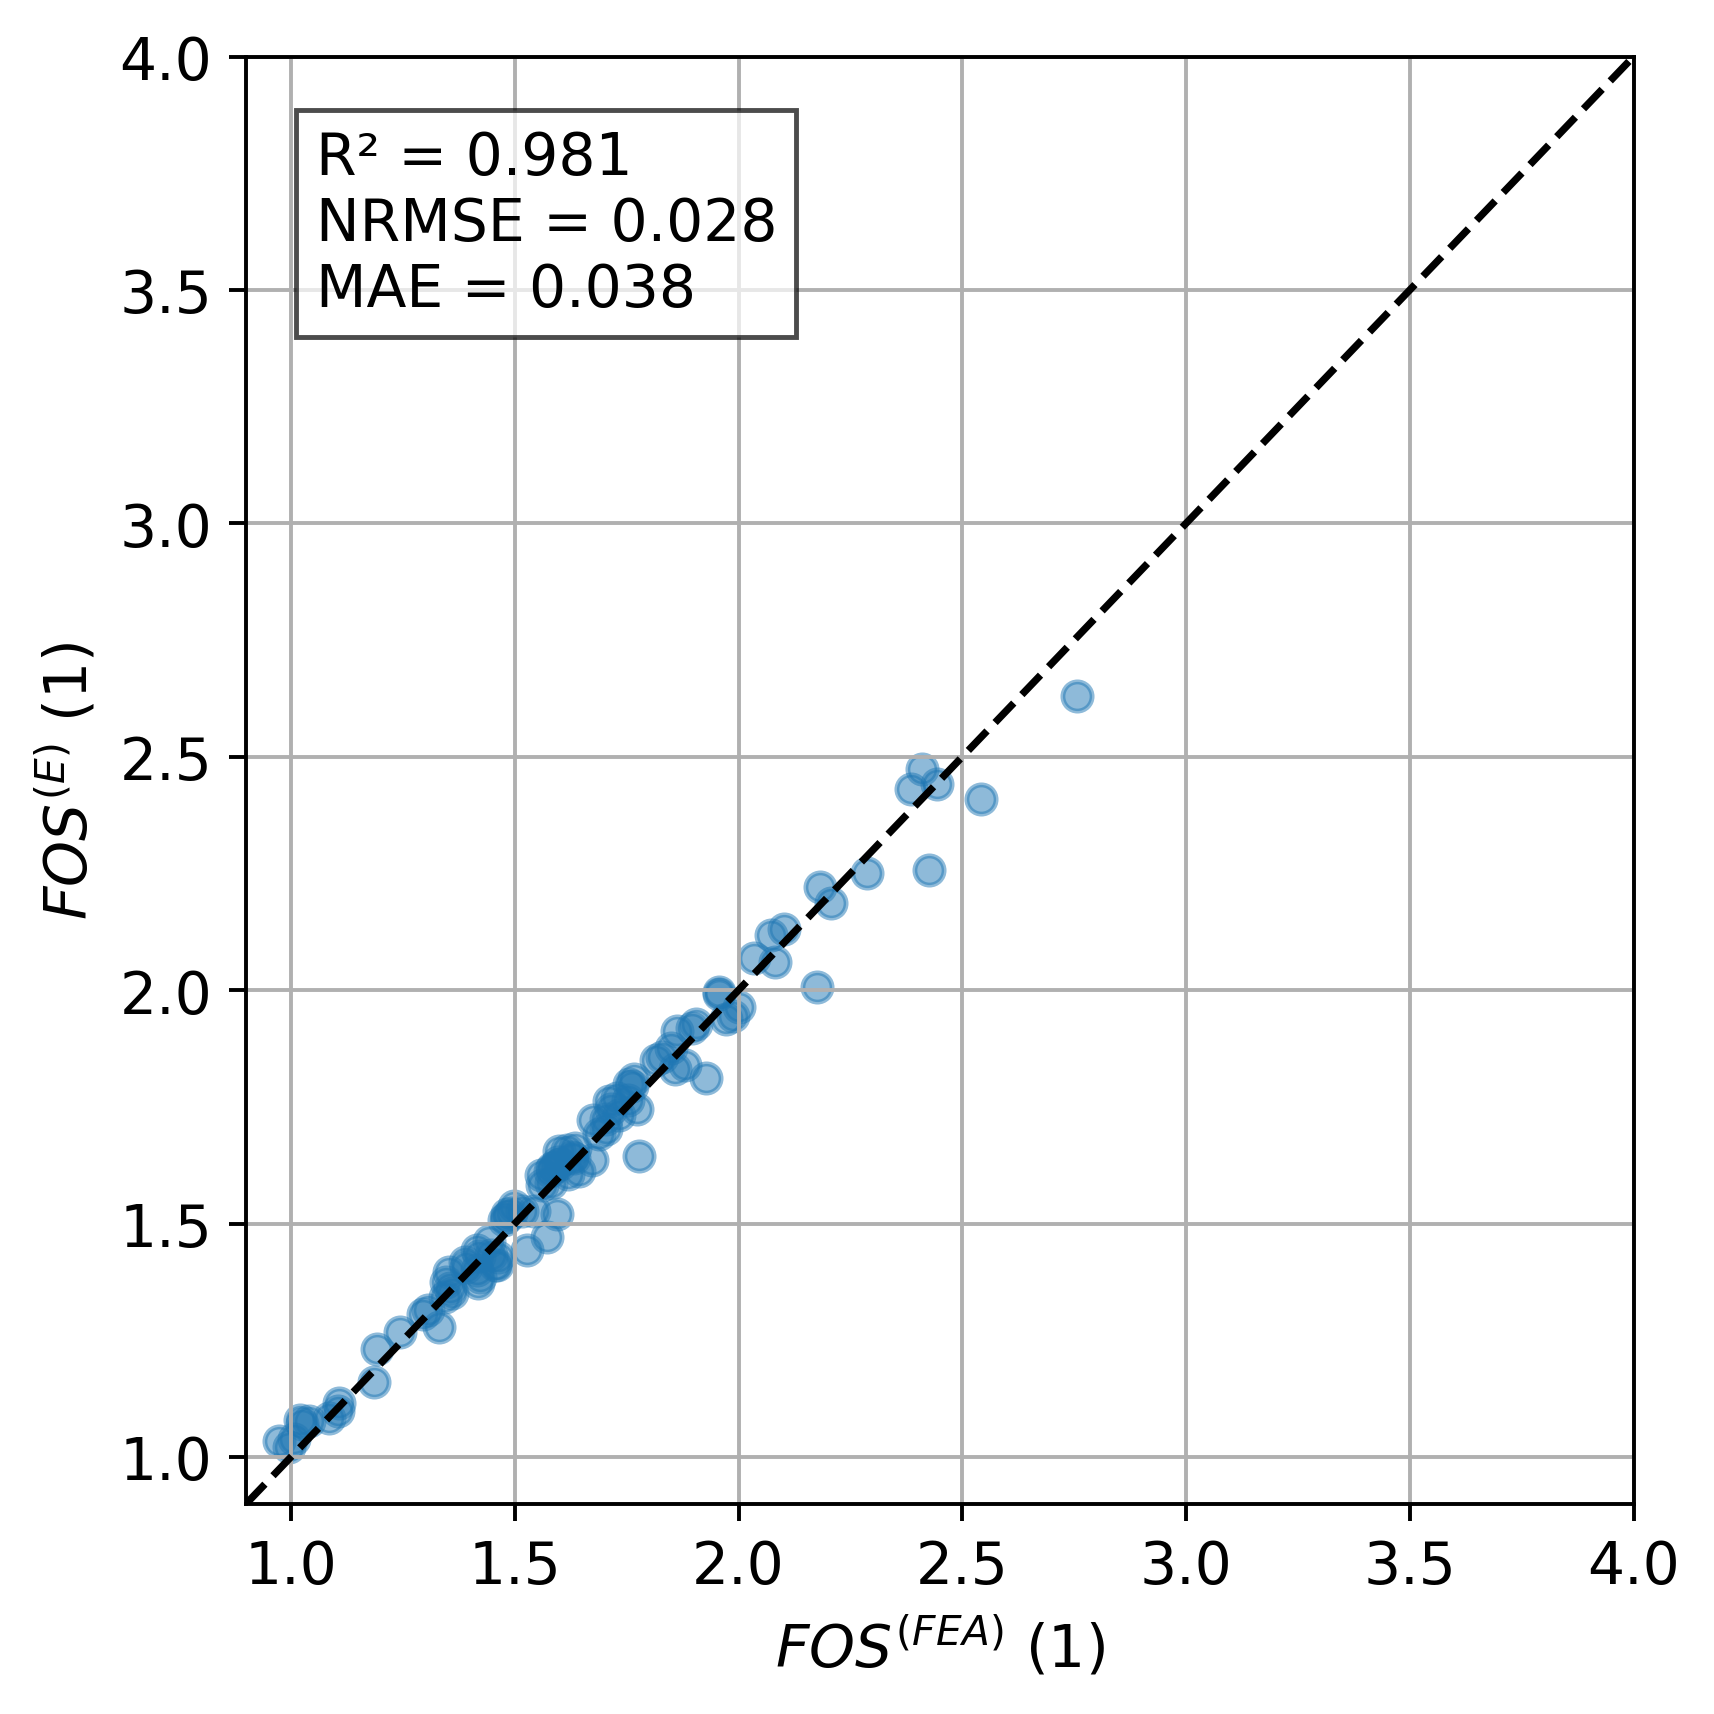

In [19]:
# FOS after excavation phase
surrogate_analyzer.evaluate_pce_model(pce_idx=0, plot_limits=[0.9, 4.0])

Test R²: 0.9949
Test NRMSE: 0.0133
Test MAE: 0.0133


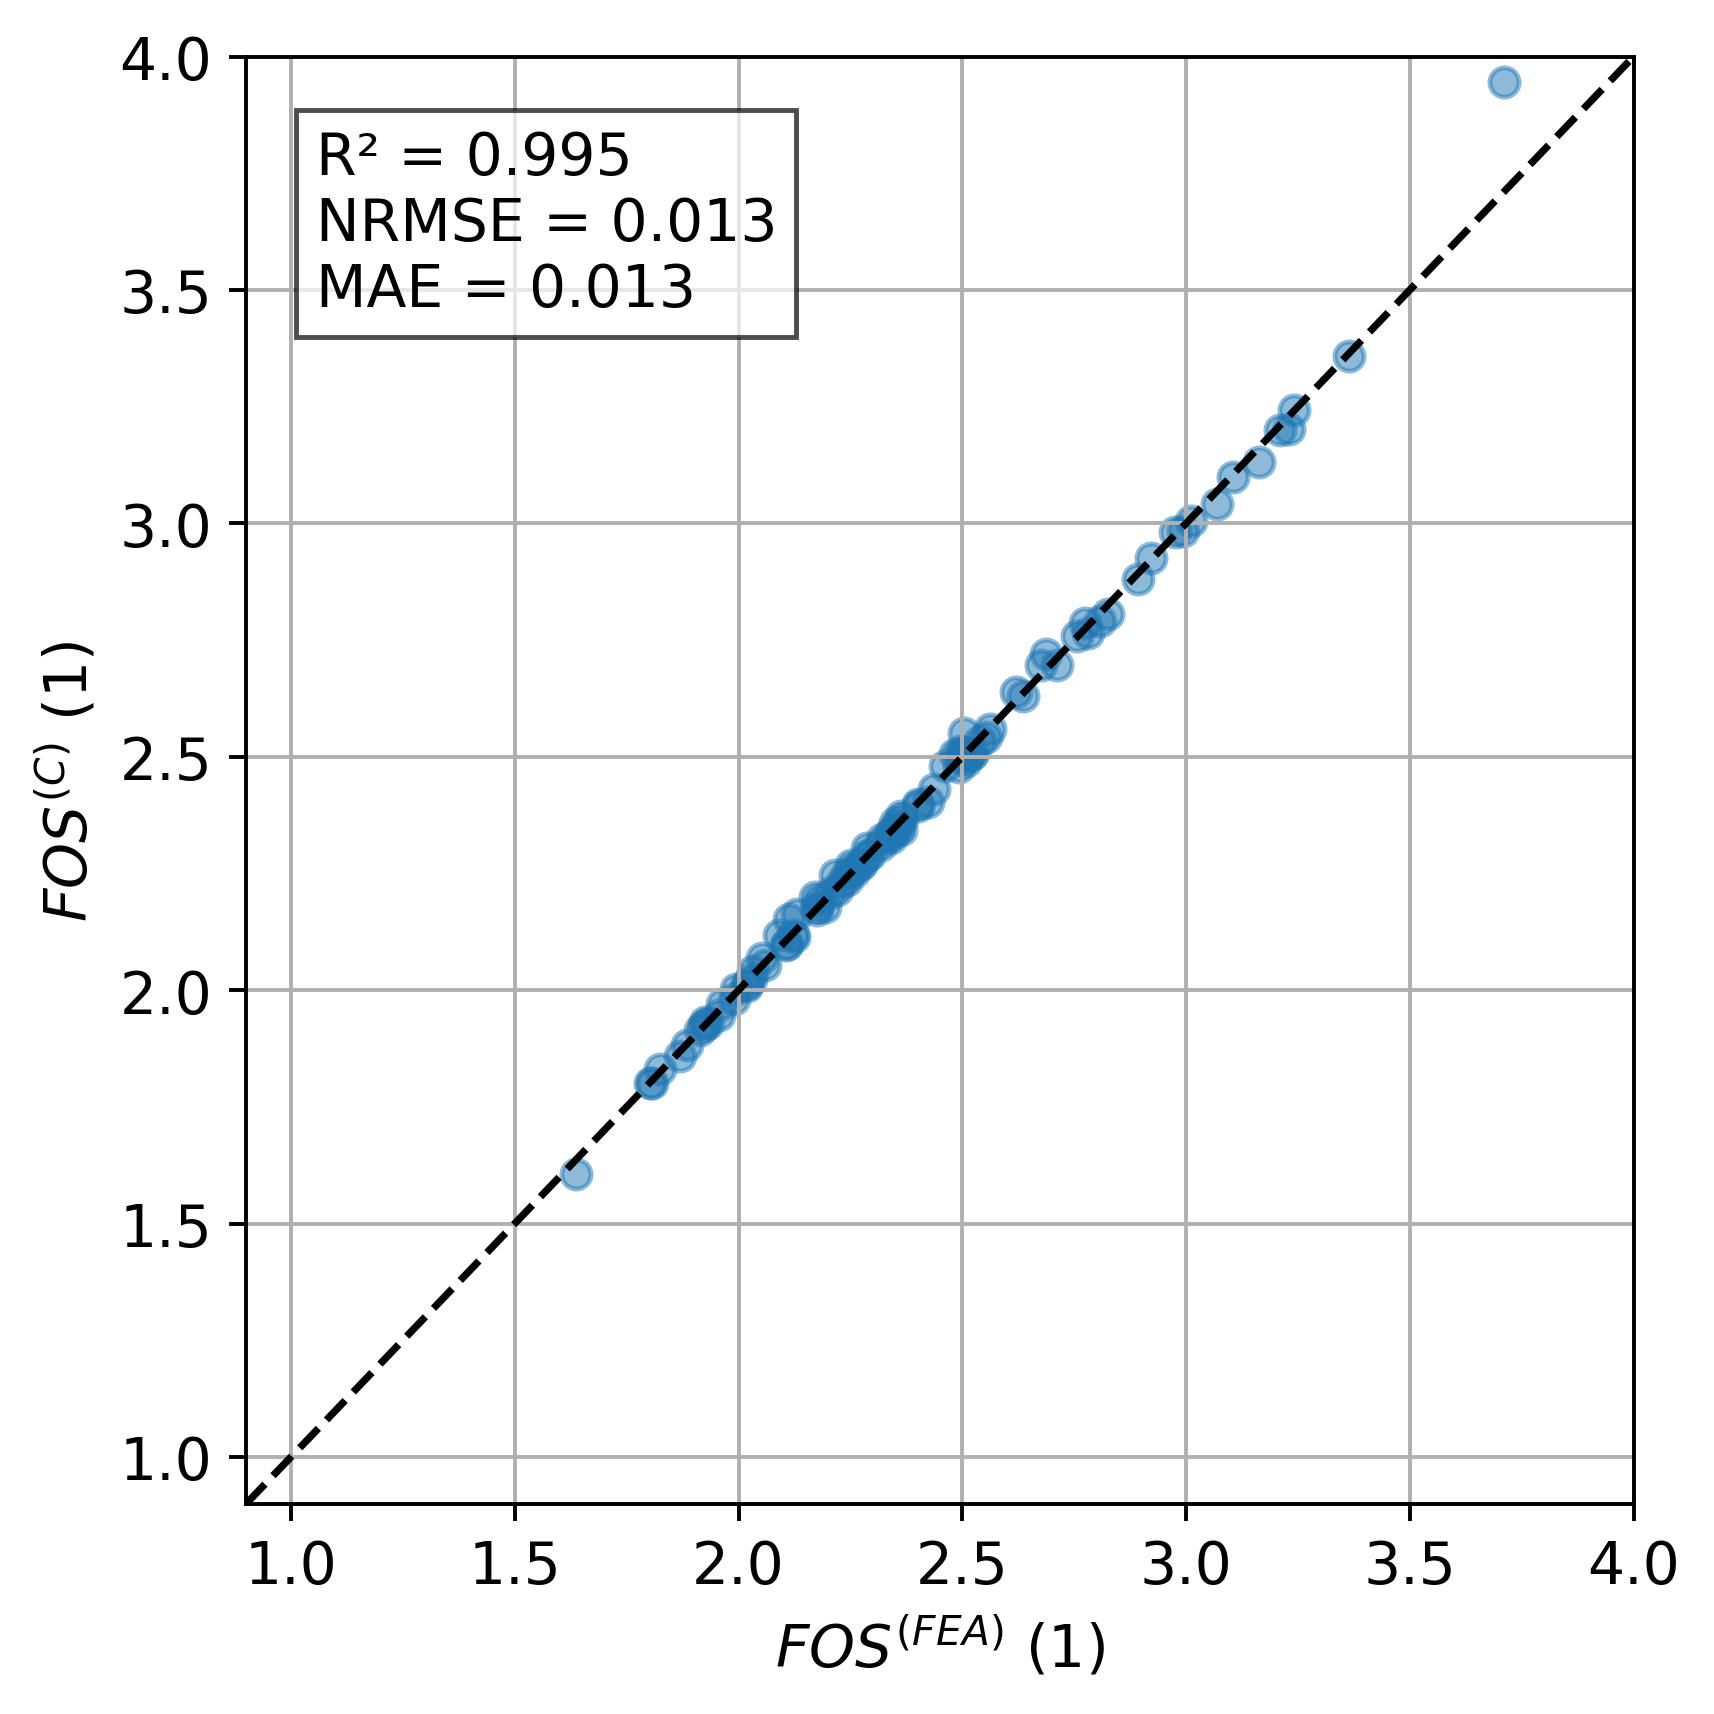

In [20]:
# FOS after cantilever phase
surrogate_analyzer.evaluate_pce_model(pce_idx=1, plot_limits=[0.9, 4.0], sm="C")

### Sample size analysis

In [21]:
plot_config = {
    "sample_sizes": [10, 20, 50, 100, 150, 200, 300],
    "r2_ylim": [0.9, 1.0],
    "nrmse_ylim": [0, 0.08],
    "labels": ["after excavation phase", "after cantilever phase"],
    "n_repeats": 5,
    "design_vars_fos_file": design_vars_fos_file
}


== Evaluating surrogate 1 (target col idx: 14) ==
Degree 1: Mean CV R² = -61.3633, MAE = 0.0864, NRMSE = 2.2367
Degree 2: Mean CV R² = -35066.8529, MAE = 4.0379, NRMSE = 58.9288
Degree 3: Mean CV R² = -75229.6596, MAE = 3.2506, NRMSE = 74.9352
Degree 4: Mean CV R² = -87226.4752, MAE = 2.9062, NRMSE = 76.4702
Best polynomial degree: 1
Degree 1: Mean CV R² = 0.9409, MAE = 0.0388, NRMSE = 0.1109
Degree 2: Mean CV R² = -249.7016, MAE = 1.7117, NRMSE = 6.0829
Degree 3: Mean CV R² = -2044.1449, MAE = 4.0888, NRMSE = 16.4765
Degree 4: Mean CV R² = -679.5138, MAE = 1.3173, NRMSE = 7.4584
Best polynomial degree: 1
Degree 1: Mean CV R² = 0.6204, MAE = 0.0371, NRMSE = 0.2094
Degree 2: Mean CV R² = -456.1033, MAE = 1.3065, NRMSE = 7.2325
Degree 3: Mean CV R² = -761.5368, MAE = 2.8000, NRMSE = 11.2843
Degree 4: Mean CV R² = -3366.0789, MAE = 2.3492, NRMSE = 17.5079
Best polynomial degree: 1
Degree 1: Mean CV R² = 0.8299, MAE = 0.0195, NRMSE = 0.1708
Degree 2: Mean CV R² = -14970.3386, MAE = 4.2154

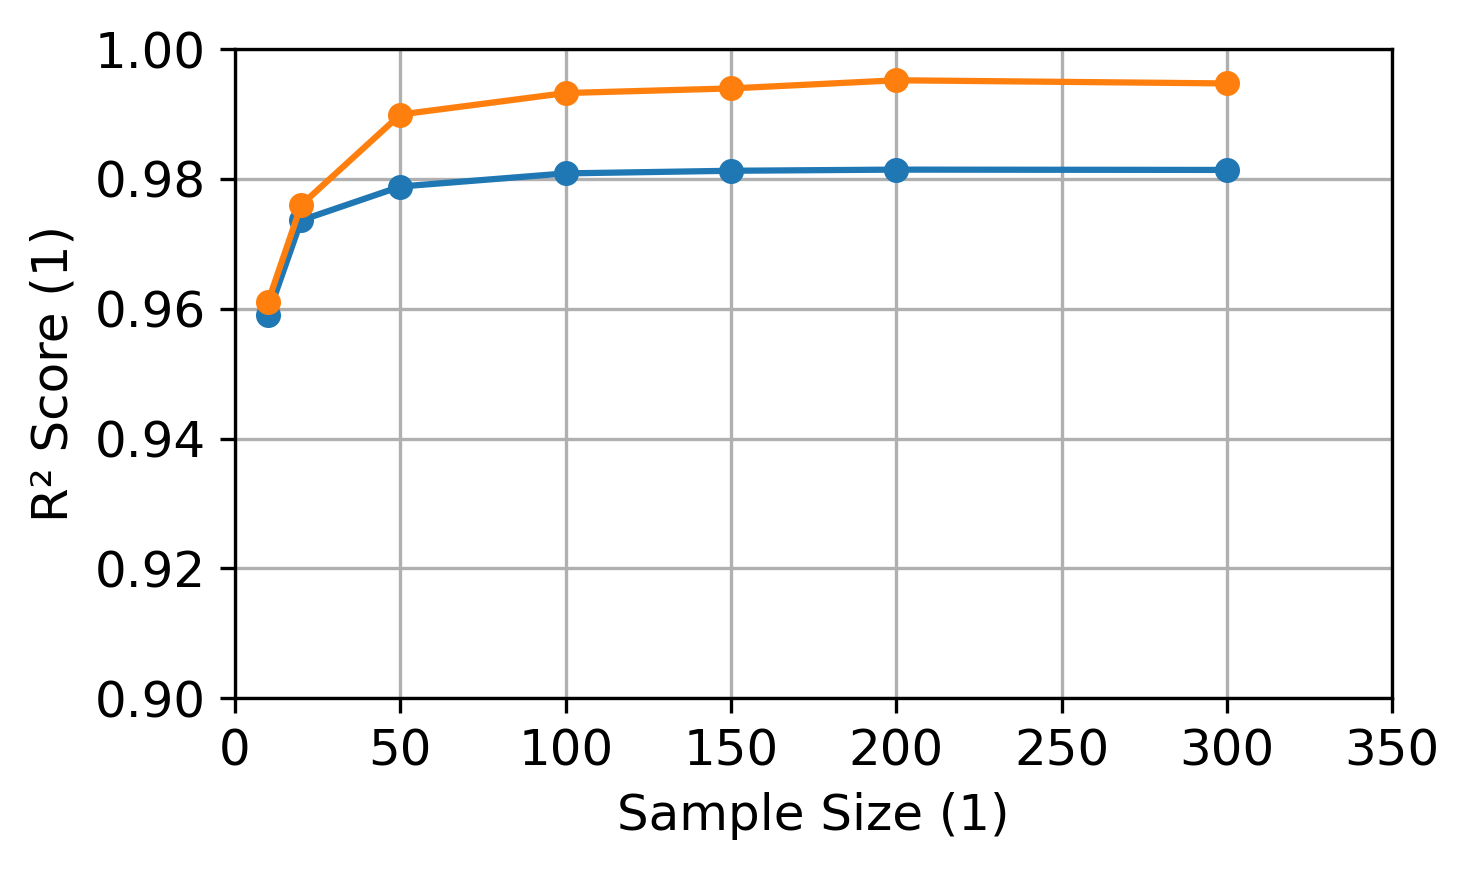

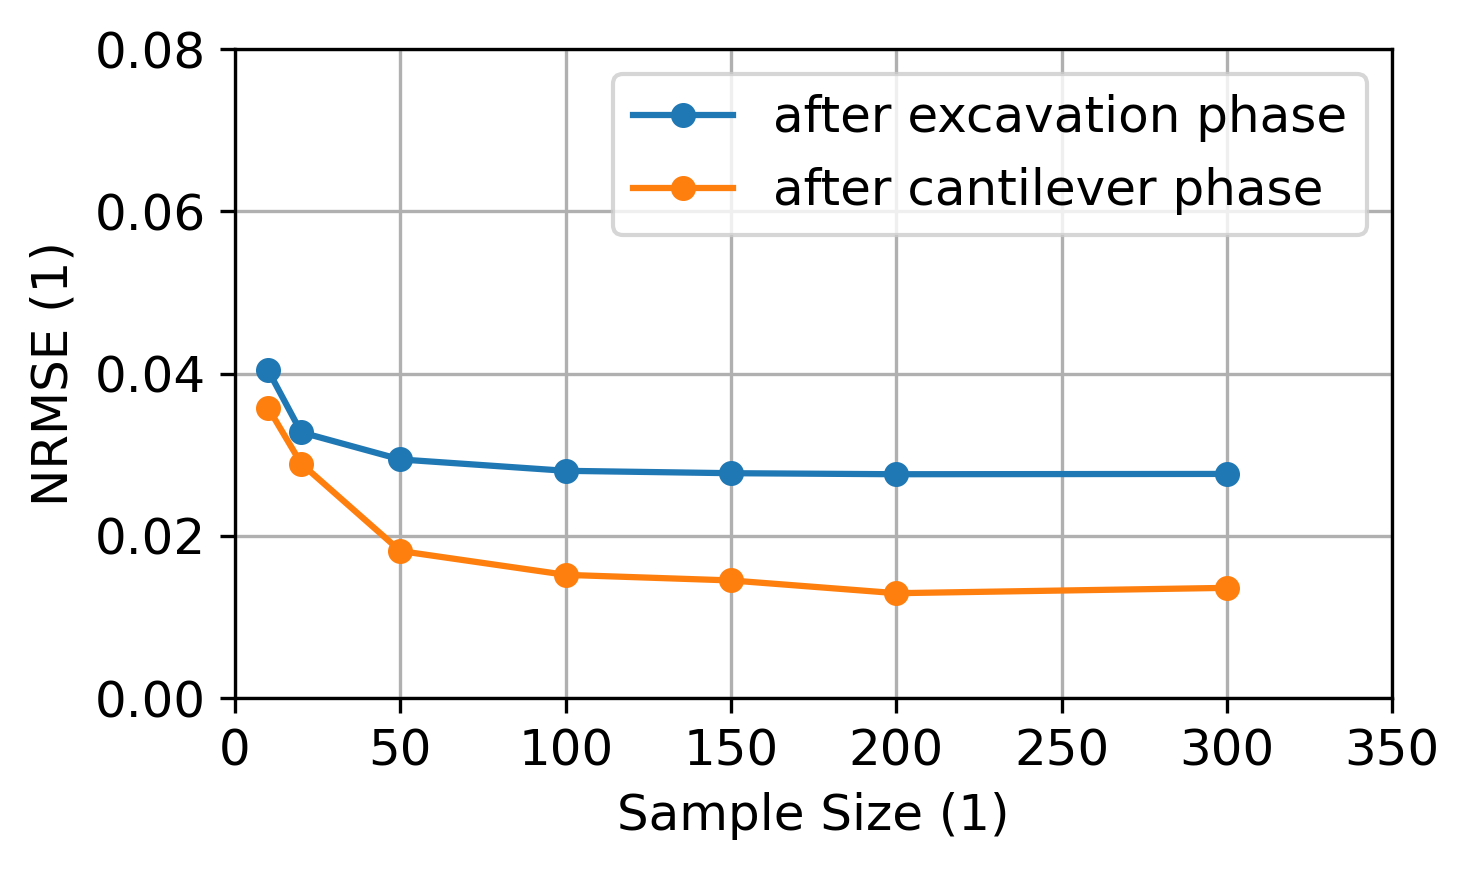

In [22]:
# Evaluate effect of training sample size on surrogate model performance
surrogate_analyzer.evaluate_sample_size_effect(design_vars_fos_file, plot_config=plot_config)

### Sensitivity analysis

#### Sobol Indices

In [23]:
plot_config = {
    "model_labels": ["FOS after excavation phase", "FOS after cantilever phase"],
    "var_labels": ["$d_{LC}$","$L_{LC}$","$c_{LC}$","$s_{u,LC}$","$s_{u,clay}$"],
    "ylim": (0, 1.0),
}


== Model 1 (FoS col idx: 14) ==
Main  Sobol: [0.04  0.032 0.    0.    0.928]
Total Sobol: [0.04  0.032 0.    0.    0.928]

== Model 2 (FoS col idx: 15) ==
Main  Sobol: [0.016 0.03  0.    0.    0.953]
Total Sobol: [0.016 0.031 0.    0.    0.954]


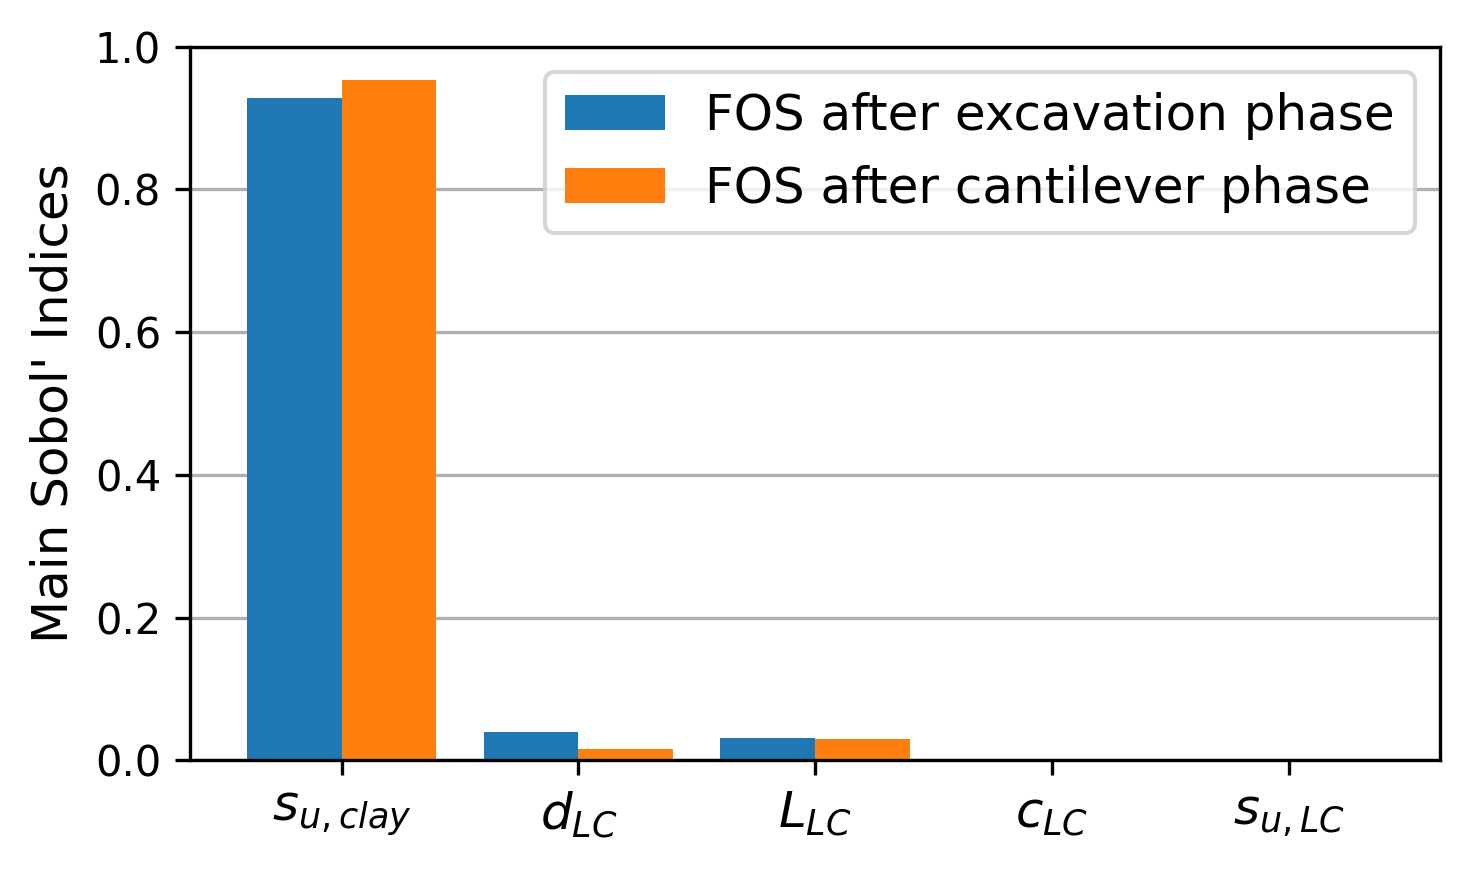

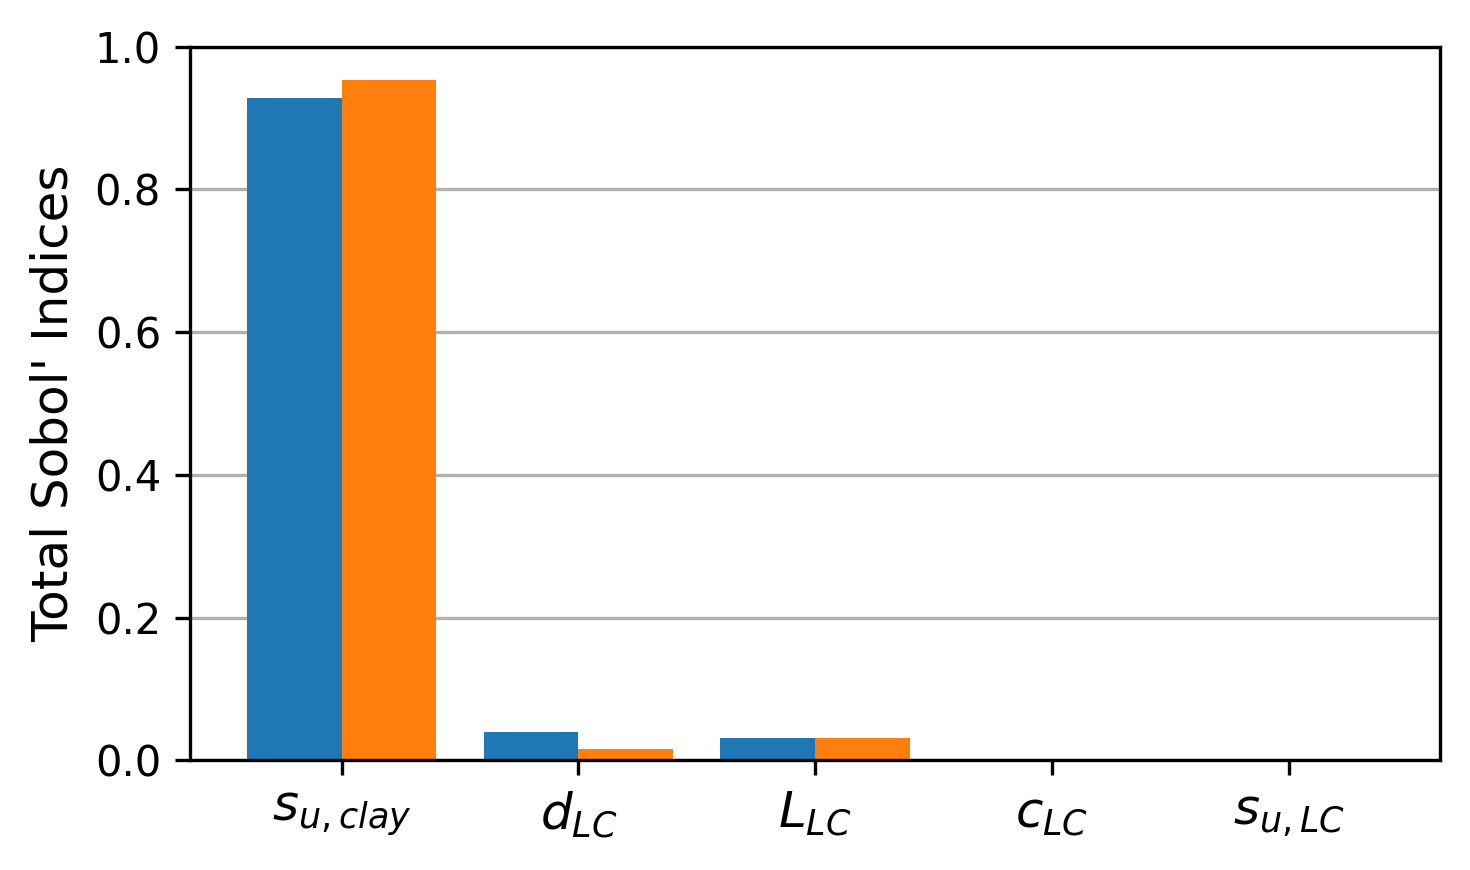

In [24]:
surrogate_analyzer.evaluate_global_sensitivity(plot_config=plot_config)

#### Univariate effects

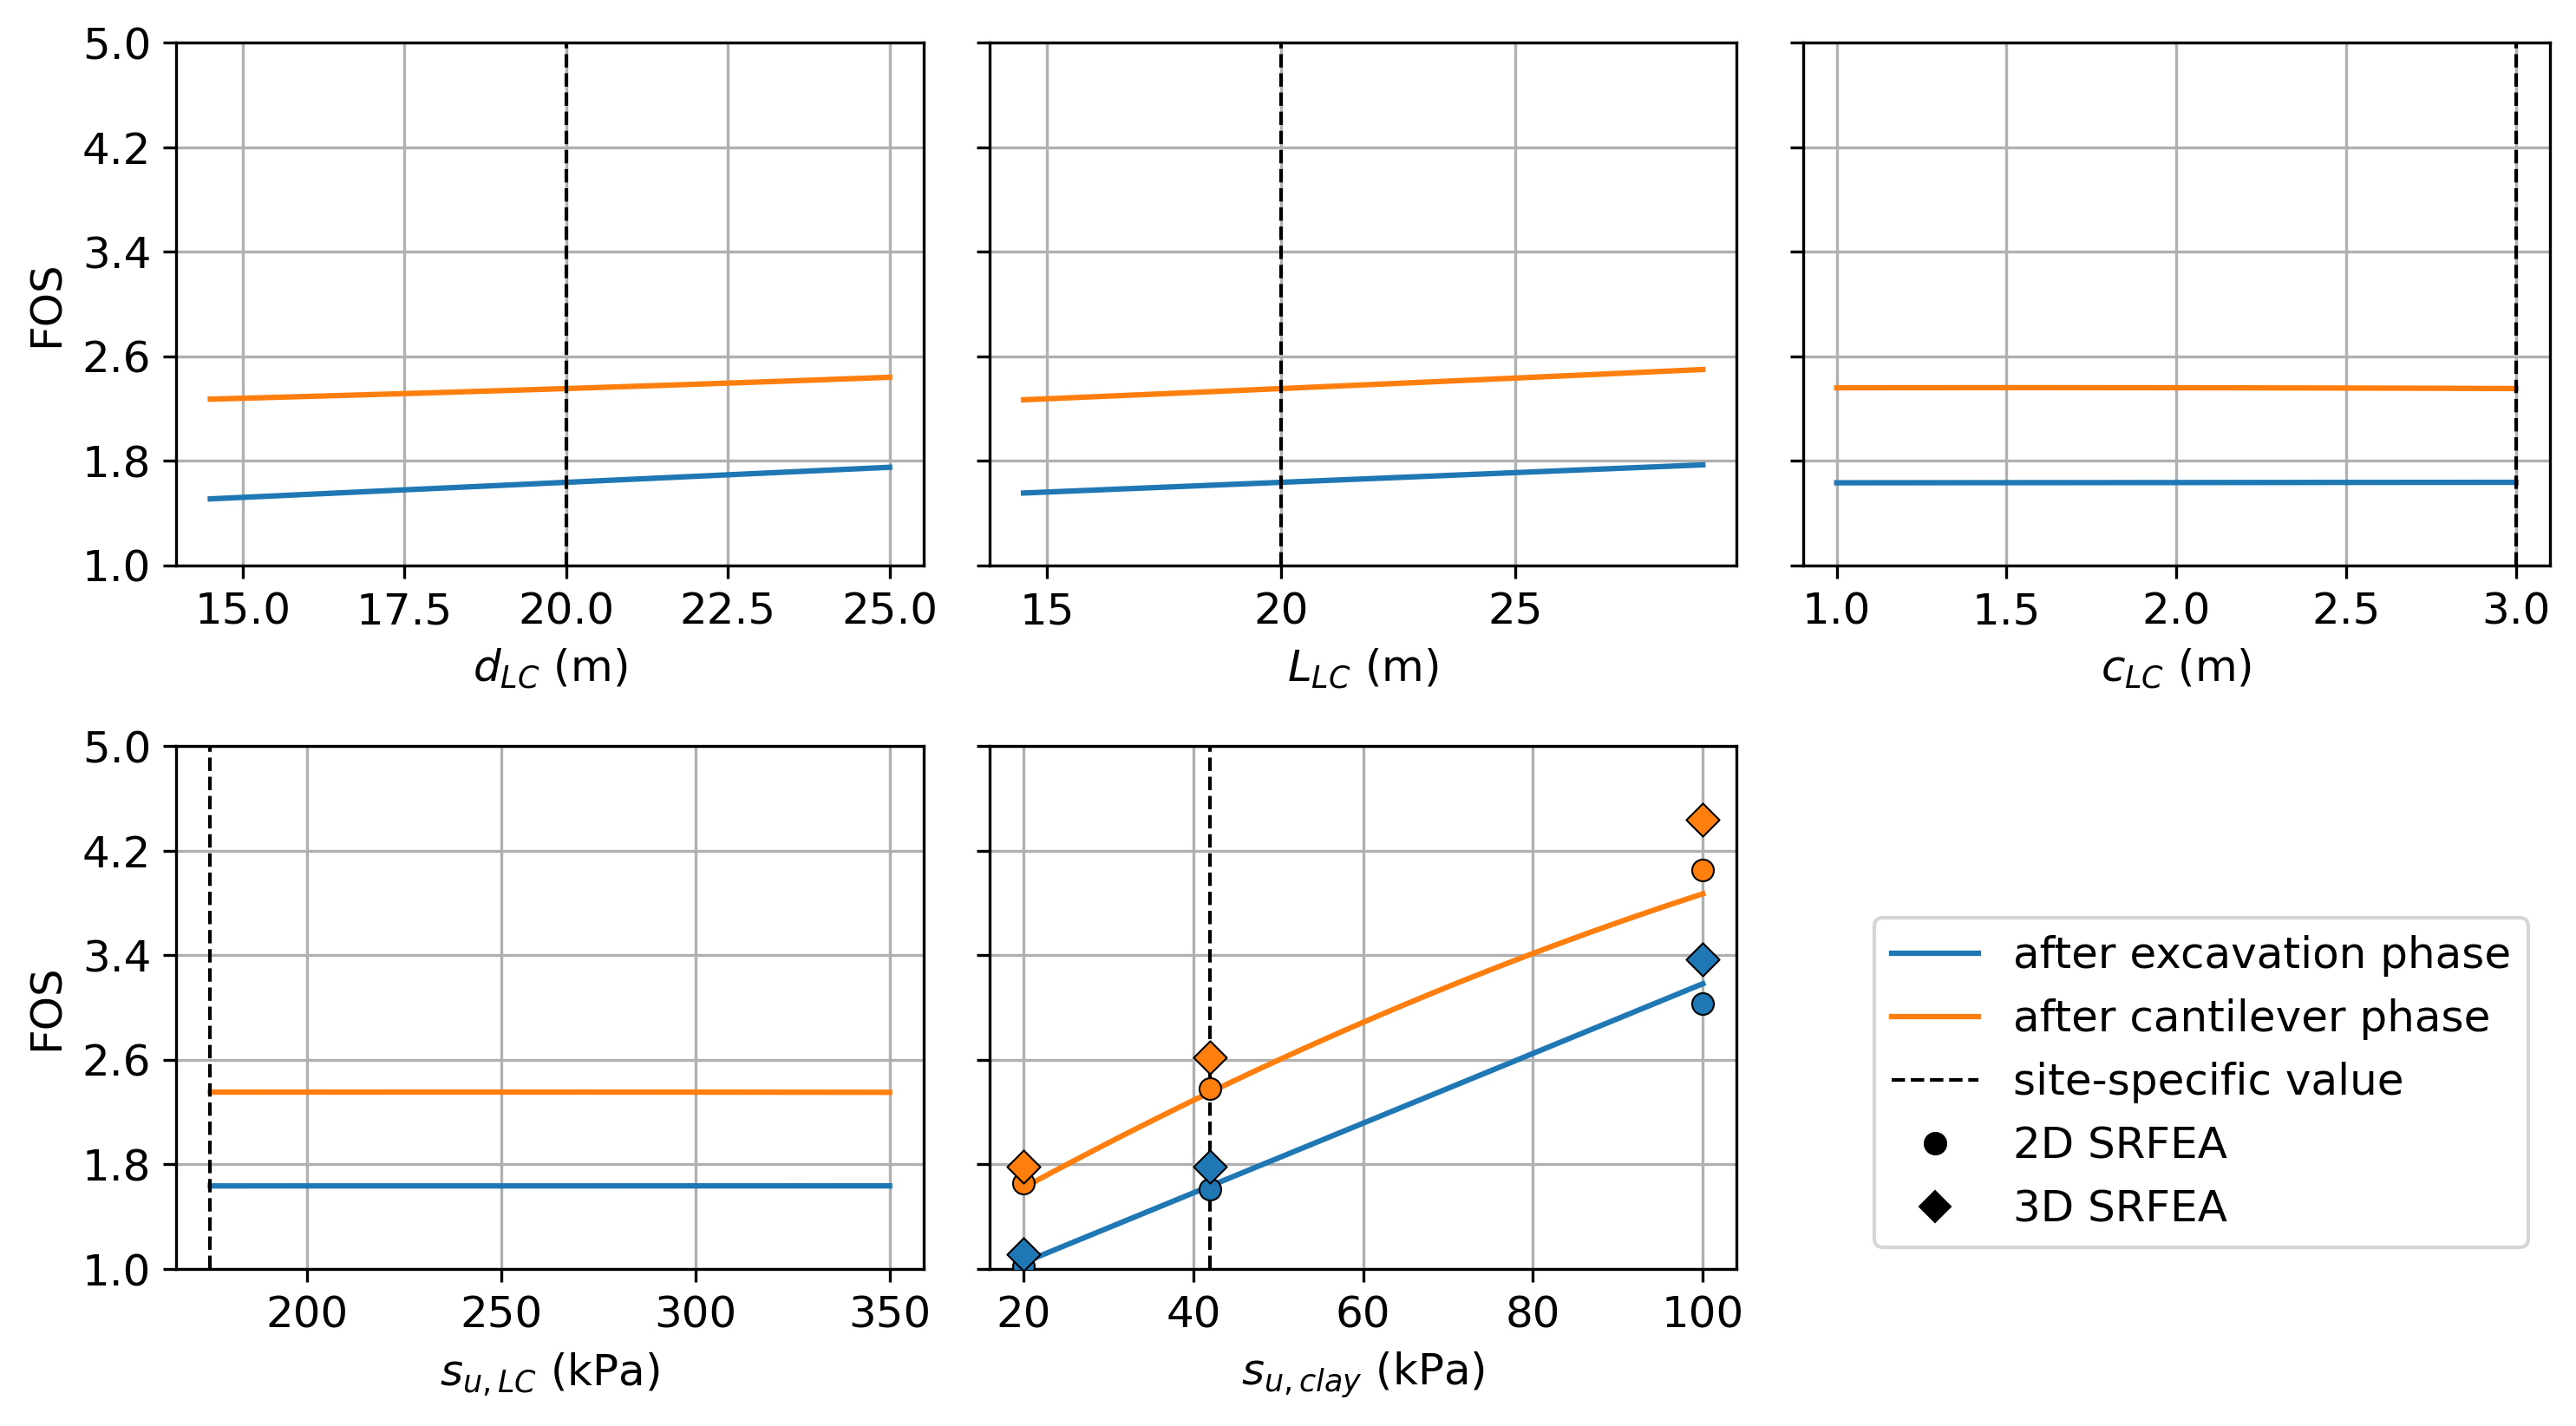

In [58]:
import importlib
import deepxtwin.surrogate.pce_surrogate_analyzer as pce_surrogate_analyzer
pce_surrogate_analyzer = importlib.reload(pce_surrogate_analyzer)

plot_config = {
    "n_points": 100,
    "x_ranges": [[14.5, 25.0], [14.5, 29.0], [1.0, 3.0], [175, 350], [20, 100]],
    "var_labels": ["$d_{LC}$ (m)","$L_{LC}$ (m)","$c_{LC}$ (m)","$s_{u,LC}$ (kPa)","$s_{u,clay}$ (kPa)"],
    "constant_values": [20.0, 20.0, 3.0, 175.0, 42.0],  # explicitly fixed values
    "y_lim": (1, 5),
    "labels": ["after excavation phase", "after cantilever phase"],
    "legend_loc": "lower right",
    # Points shown only in last subplot (x = s_{u,clay})
    # Format: (x, y, model_idx), where model_idx maps to labels[model_idx]
    "last_subplot_points_3d": [
        (20, 1.11, 0),
        (20, 1.78, 1),
        (42, 1.78, 0),
        (42, 2.62, 1),
        (100, 3.37, 0),
        (100, 4.44, 1),
    ],
    "last_subplot_points_2d": [
        (20, 1.02, 0),
        (20, 1.66, 1),
        (42, 1.61, 0),
        (42, 2.38, 1),
        (100, 3.03, 0),
        (100, 4.05, 1),
    ],
}

surrogate_analyzer_updated = pce_surrogate_analyzer.PCE_Surrogate_Analyzer(
    [surrogate_model_excavation, surrogate_model_cantilever]
 )
surrogate_analyzer_updated.evaluate_univariate_effects(plot_config)

In [26]:
# Check available attributes and methods in the first PCE model
dir(surrogate_analyzer.pce_models[0])

['X_test',
 'X_train',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'best_coeffs',
 'best_degree',
 'best_poly_expansion',
 'clean_rawdata',
 'data',
 'data_cleaned',
 'design_vars_cleaned',
 'design_vars_fos_file_path',
 'fos_cleaned',
 'fos_col_idx',
 'get_model_by_degree',
 'inspect_rawdata',
 'joint_dist',
 'load_rawdata',
 'models_by_degree',
 'predict',
 'strat_test',
 'strat_train',
 'train_fraction',
 'train_pce_model',
 'train_test_split',
 'y_test',
 'y_train']

In [27]:
# Access training data of the first PCE model
surrogate_analyzer.pce_models[0].X_train

array([[ 24.62,  25.75,   2.76, 309.08,  41.62],
       [ 16.05,  25.51,   2.34, 258.24,  44.52],
       [ 17.58,  26.18,   1.07, 226.73,  48.76],
       ...,
       [ 15.79,  17.22,   1.14, 244.21,  57.64],
       [ 16.78,  28.07,   2.57, 224.52,  30.66],
       [ 19.56,  22.49,   1.15, 320.59,  30.78]], shape=(400, 5))

### Response surface

In [28]:
# shown: d_{LC} x s_{u,LC}
plot_config = {
    "n_points": 100,
    "x_ranges": [              # Required for full input domain
        [14.5, 25.0],          # var 0 (varied)
        [14.5, 29.0],          # var 1 (fixed)
        [1.0, 3.0],            # var 2 (fixed)
        [175.0, 350.0],        # var 3 (fixed)
        [15.0, 105.0]          # var 4 (varied)
    ],
    "constant_values": [20.0, 20.0, 3.0, 175.0, 42.0],
    "var_labels": [
        "$d_{LC}$ (m)", 
        "$L_{LC}$ (m)", 
        "$c_{LC}$ (m)", 
        "$s_{u,LC}$ (kPa)", 
        "$s_{u,clay}$ (kPa)"
    ],
    "output_label": r"$FOS^{(E)}$ (1)",
    "plot_labels": [
        "$d_{LC}$",
        "$s_{u,LC}$"],
    "x_ticks": [14.0, 16.0, 18.0, 20.0, 22.0, 24.0],
    # "y_ticks": [10, 30, 50, 70, 90, 110],
    "zlim": [0.5, 4.0]
}

[[ 20.  20.   3. 175.  42.]
 [ 20.  20.   3. 175.  42.]
 [ 20.  20.   3. 175.  42.]
 ...
 [ 20.  20.   3. 175.  42.]
 [ 20.  20.   3. 175.  42.]
 [ 20.  20.   3. 175.  42.]]
Index of min train set value of var2_idx: 341
y_test_pred at min var2_idx: 0.9920757676019603
Index of min test set value of var2_idx: 69
y_test_pred at min var2_idx: 1.0374100965411206


C:\Users\AzG\OneDrive - NGI\01_Projects\02_Campus_Ullevål\azure\sp14-wp4-deepxtwin\deepxtwin\surrogate\pce_surrogate_analyzer.py:658: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



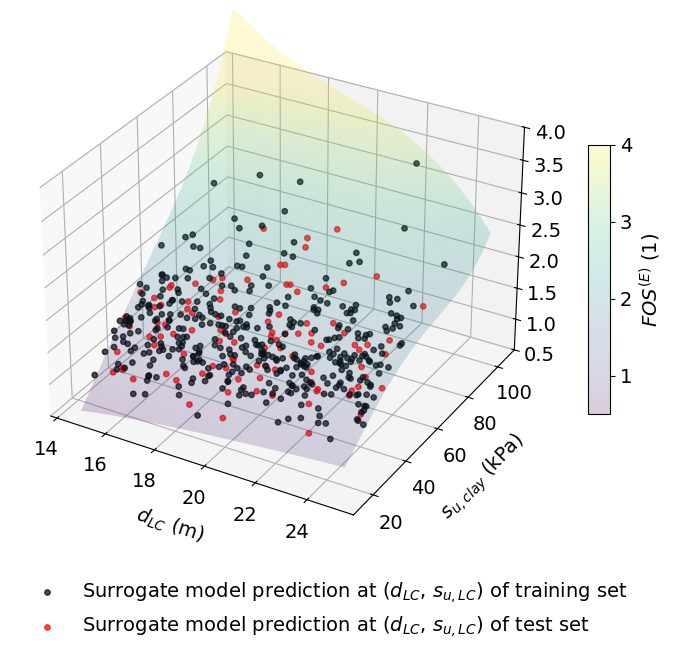

In [29]:
surrogate_analyzer.evaluate_response_surface(
    pce_idx=0,
    var1_idx=0,   # d_LC varied
    var2_idx=4,   # s_{u,LC} varied
    degree=4,   
    plot_config=plot_config,
)

[[ 20.  20.   3. 175.  42.]
 [ 20.  20.   3. 175.  42.]
 [ 20.  20.   3. 175.  42.]
 ...
 [ 20.  20.   3. 175.  42.]
 [ 20.  20.   3. 175.  42.]
 [ 20.  20.   3. 175.  42.]]
Index of min train set value of var2_idx: 341
y_test_pred at min var2_idx: 0.9920757676019603
Index of min test set value of var2_idx: 69
y_test_pred at min var2_idx: 1.0374100965411206


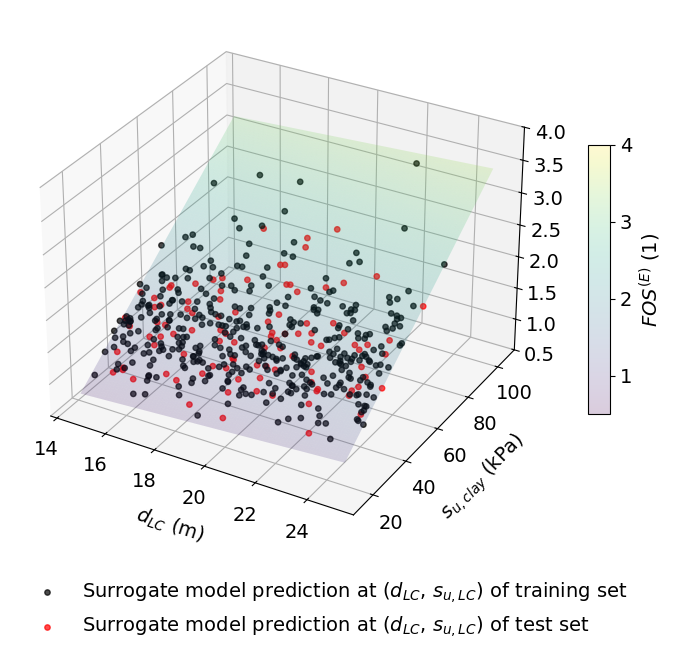

In [30]:
surrogate_analyzer.evaluate_response_surface(
    pce_idx=0,
    var1_idx=0,   # d_LC varied
    var2_idx=4,   # s_{u,LC} varied
    degree=1,   
    plot_config=plot_config,
)

In [31]:
# shown: L_{LC} x s_{u,LC}
plot_config = {
    "n_points": 100,
    "x_ranges": [              # Required for full input domain
        [14.5, 25.0],          # var 0 
        [14.5, 29.0],          # var 1 (varied)
        [1.0, 3.0],            # var 2 
        [175.0, 350.0],        # var 3 
        [15.0, 105.0]          # var 4 (varied)
    ],
    "constant_values": [20.0, 20.0, 3.0, 175.0, 42.0],
    "var_labels": [
        "$d_{LC}$ (m)", 
        "$L_{LC}$ (m)", 
        "$c_{LC}$ (m)", 
        "$s_{u,LC}$ (kPa)", 
        "$s_{u,clay}$ (kPa)"
    ],
    "plot_labels": [
        "$L_{LC}$",
        "$s_{u,LC}$"],
    # "x_ticks": [14.0, 16.0, 18.0, 20.0, 22.0, 24.0, 26.0, 28.0],
    "zlim": [0.5, 4.0]
}

[[ 20.  20.   3. 175.  42.]
 [ 20.  20.   3. 175.  42.]
 [ 20.  20.   3. 175.  42.]
 ...
 [ 20.  20.   3. 175.  42.]
 [ 20.  20.   3. 175.  42.]
 [ 20.  20.   3. 175.  42.]]
Index of min train set value of var2_idx: 341
y_test_pred at min var2_idx: 0.9920757676019603
Index of min test set value of var2_idx: 69
y_test_pred at min var2_idx: 1.0374100965411206


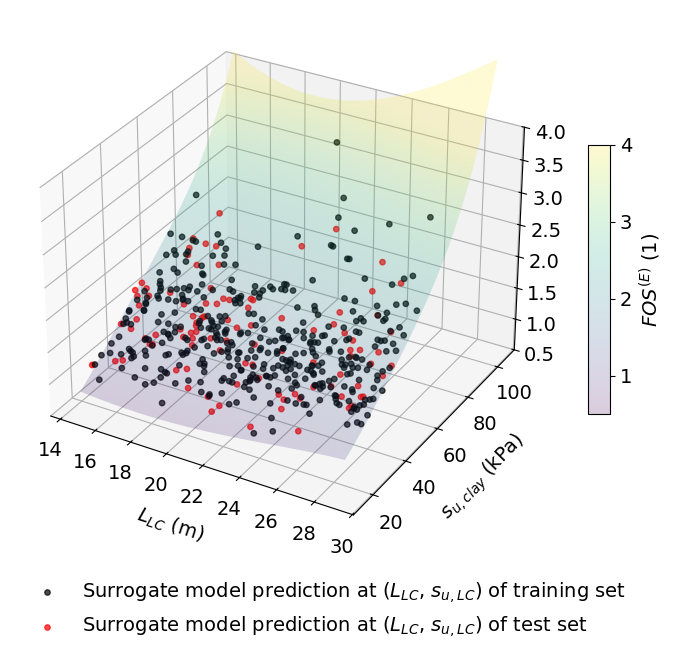

In [32]:
surrogate_analyzer.evaluate_response_surface(
    pce_idx=0,
    var1_idx=1,   # L_{LC} varied
    var2_idx=4,   # s_{u,LC} varied
    degree=4,   
    plot_config=plot_config,
)

[[ 20.  20.   3. 175.  42.]
 [ 20.  20.   3. 175.  42.]
 [ 20.  20.   3. 175.  42.]
 ...
 [ 20.  20.   3. 175.  42.]
 [ 20.  20.   3. 175.  42.]
 [ 20.  20.   3. 175.  42.]]
Index of min train set value of var2_idx: 341
y_test_pred at min var2_idx: 0.9920757676019603
Index of min test set value of var2_idx: 69
y_test_pred at min var2_idx: 1.0374100965411206


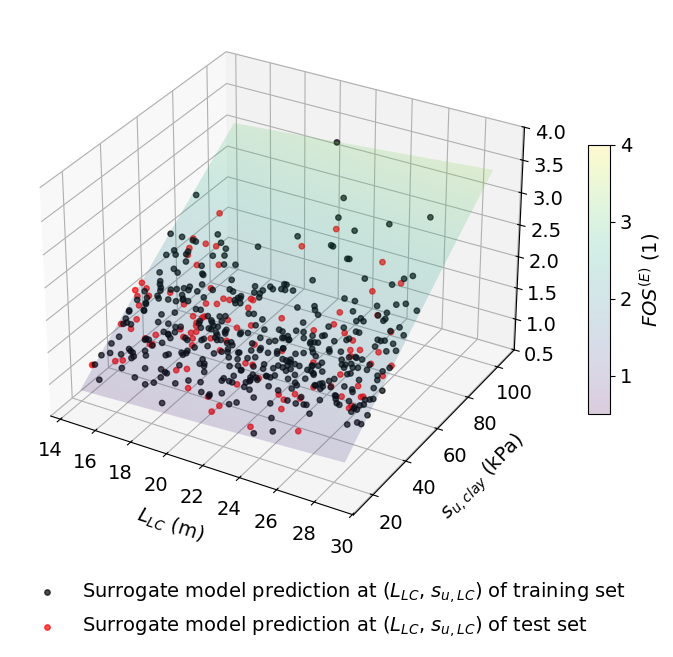

In [33]:
surrogate_analyzer.evaluate_response_surface(
    pce_idx=0,
    var1_idx=1,   # L_{LC} varied
    var2_idx=4,   # s_{u,LC} varied
    degree=2,   
    plot_config=plot_config,
)

### Uncertainty propagation analysis

In [34]:
# NOTE: The Model expects the design variables in the following order: "$d_{LC}$ (m)", "$L_{LC}$ (m)", "$c_{LC}$ (m)", "$s_{u,LC}$ (kPa)", "$s_{u,clay}$ (kPa)"

#### Provide input

In [35]:
mean = 42                                   # Mean of the uncertain (lognormal) parameter
cov = 0.3                                   # COV of the uncertain (lognormal) parameter
fixed_inputs = [20.0, 20.0, 3.0, 175]       # 4 fixed parameters according to Monsås et al. (2024) and Løyland et al. (2025)

In [36]:
dist = InputDistributionFactory(mean=mean, cov=cov, fixed_values=fixed_inputs).sample(1000000, debug=True)
# NOTE: The distribution shows mean 42 and std 42 x 0.3 = 12.6 => validated

Sample Summary:
       $d_{LC}$ (m)  $L_{LC}$ (m)  $c_{LC}$ (m)  $s_{u,LC}$ (kPa)  \
count     1000000.0     1000000.0     1000000.0         1000000.0   
mean           20.0          20.0           3.0             175.0   
std             0.0           0.0           0.0               0.0   
min            20.0          20.0           3.0             175.0   
25%            20.0          20.0           3.0             175.0   
50%            20.0          20.0           3.0             175.0   
75%            20.0          20.0           3.0             175.0   
max            20.0          20.0           3.0             175.0   

       $s_{u,clay}$ (kPa)  
count      1000000.000000  
mean            42.015942  
std             12.604731  
min              9.590070  
25%             33.012672  
50%             40.245165  
75%             49.041830  
max            157.388045  


#### Sample size effect on statistical moments of surrogate FoS predictions

In [37]:
uq = UQAnalysis(surrogate_analyzer.pce_models[0], mean_input=mean, fixed_inputs=fixed_inputs)


=== Mean and 95% Confidence Interval Summary ===
 Sample Size     Mean  95% CI Lower  95% CI Upper  5% Percentile
         100 1.602974      1.539069      1.666879       1.170929
        1000 1.625454      1.604866      1.646043       1.169037
       10000 1.628596      1.622116      1.635076       1.178844
      100000 1.634839      1.632767      1.636912       1.178582
     1000000 1.636357      1.635698      1.637015       1.178812

=== Plotting ===


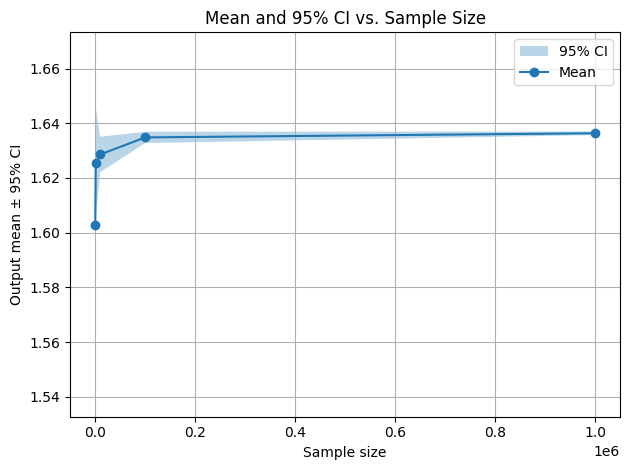

In [38]:
# Assess convergence of mean and confidence interval of FoS with increasing number of samples
uq.analyze_mean_ci_vs_samples(cov=0.3, sample_sizes=[100, 1000, 10000, 100000, 1000000])  # 10E6 samples based on example Sudret (2014)

#### COV effect on surrogate FoS predictions


=== Mean and 95% Confidence Interval Summary by COV ===
   COV  Sample Size   Mean  95% CI Lower  95% CI Upper  5% Percentile
0.1000       100000 1.6356        1.6349        1.6363         1.4621
0.1500       100000 1.6355        1.6344        1.6365         1.3830
0.2000       100000 1.6353        1.6339        1.6366         1.3094
0.2500       100000 1.6351        1.6333        1.6368         1.2413
0.3000       100000 1.6348        1.6328        1.6369         1.1786

=== Plotting ===


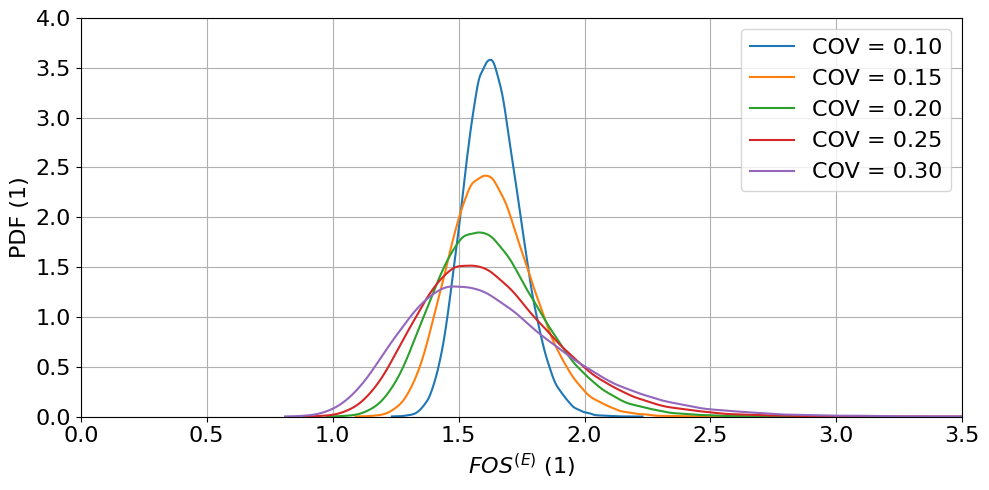

In [39]:
uq.analyze_kde_vs_cov(cov_list=[0.1, 0.15, 0.2, 0.25, 0.3], nsamples=100000) # Should be increased to 10E6 at least

#### COV effect on pf


=== Probability of Failure and Reliability Index Summary ===
 COV  FS Limit  Sample Size      P_f        β
0.10       1.0      1000000 0.000000      inf
0.15       1.0      1000000 0.000000      inf
0.20       1.0      1000000 0.000023 4.075073
0.25       1.0      1000000 0.000533 3.272502
0.30       1.0      1000000 0.003341 2.712291

=== Plotting ===


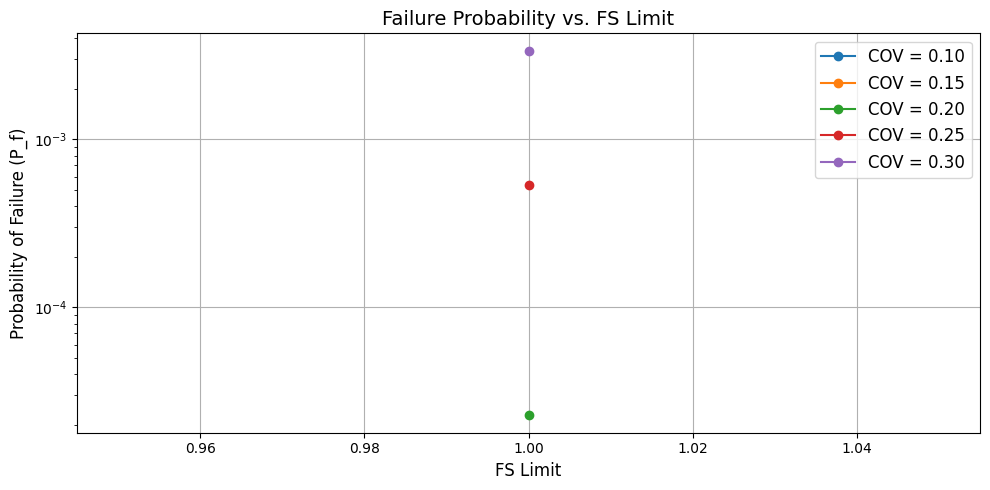

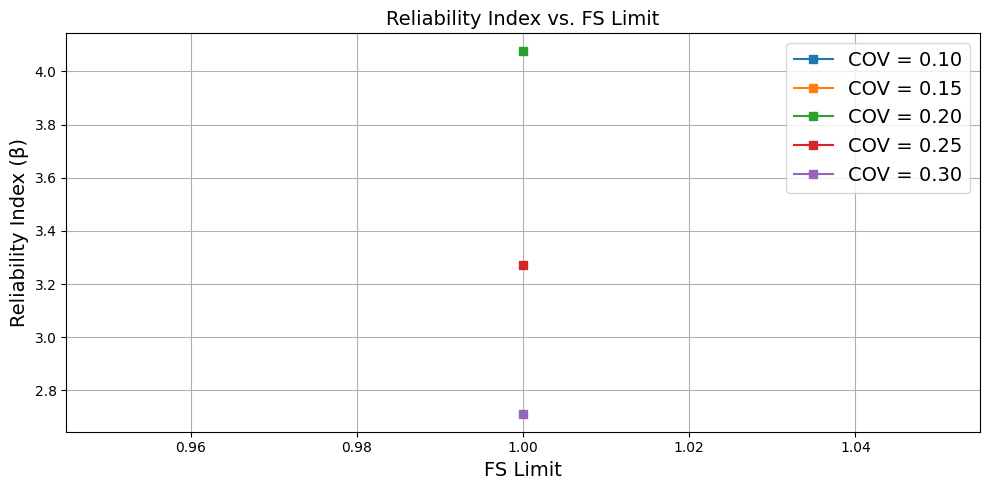

In [40]:
# 10^6 samples
uq.analyze_pf_beta_vs_fs_cov(cov_list=[0.1, 0.15, 0.2, 0.25, 0.3], 
                             fs_limits=[1.0], #, 1.2, 1.4, 1.6], 
                             nsamples=1000000) # May be increased to 10E7 at least